# **Imports**

In [1]:

from earthscape.constants import VERSION, ASSETS_DIR, MODEL_DIR, SG_MAPPING, SG_COLORS
from earthscape.models import create_unet_seg, create_deeplabv3p_seg, create_segformer_seg
from earthscape.loaders import ESDataset_Classification
from earthscape.evaluation import test_model_seg

import os
import glob
import yaml
import numpy as np
import pandas as pd
from scipy.stats import t
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
import seaborn as sns

from scipy import stats

from earthscape.analysis.data_processing import parse_input_label, parse_features, spatial_support

import matplotlib as mpl
mpl.rcParams["svg.fonttype"] = "none"

# **Setup**

In [2]:
#############################################
# Setup input and output directories & paths
#############################################

# directory of experiments
exp_dir = r'../experiments/baselines/segmentation'

# single modality experiments...
single_root = os.path.join(exp_dir, 'single')
single_dirs = glob.glob(f"{single_root}/*")

# multi-scale modality experiments...
ms_root = os.path.join(exp_dir, 'multiscale')
ms_dirs = glob.glob(f"{ms_root}/*")

# multimodal experiments modalities...
mm_root = os.path.join(exp_dir, 'multimodal')
mm_dirs = glob.glob(f"{mm_root}/*")

# output directory for visualizations...
assets_dir = os.path.join(exp_dir.replace(MODEL_DIR, ASSETS_DIR))
if not os.path.isdir(assets_dir):
    os.makedirs(assets_dir)


# **Model Performance**

## *Experiment Compilation*

In [3]:
##################################################
# Compile Global Performance Metrics - Single
##################################################

# initialize df
df_single = pd.DataFrame(columns=['model', 'encoder', 'input'])

# collect global data from all experiments...
for idx, d in enumerate(single_dirs):
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0].split('-')[0]
    encoder_name = meta[0].split('-')[1]
    modalities = meta[1]

    # in-domain...
    id_global_path = os.path.join(d, 'id_overall.csv')
    id = pd.read_csv(id_global_path)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_global_path = os.path.join(d, 'cd_overall.csv')
    cd = pd.read_csv(cd_global_path)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge datasets...
    df_single.loc[idx, 'model'] = model_name
    df_single.loc[idx, 'encoder'] = encoder_name
    df_single.loc[idx, 'input'] = modalities
    df_single.loc[idx, id.columns] = id.values
    df_single.loc[idx, cd.columns] = cd.values


df_single.head()

,model,encoder,input,macro_iou (id),macro_dice (id),macro_precision (id),macro_recall (id),micro_iou (id),micro_dice (id),micro_precision (id),...,macro_iou (cd),macro_dice (cd),macro_precision (cd),macro_recall (cd),micro_iou (cd),micro_dice (cd),micro_precision (cd),micro_recall (cd),mean_hd (cd),mean_hd95 (cd)
0,deeplabv3p,resnet50,dem,0.456716,0.520123,0.578694,0.537224,0.745188,0.853991,0.853991,...,0.277540,0.326148,0.394428,0.359175,0.590953,0.742892,0.742892,0.742892,118.598309,102.303001
1,deeplabv3p,resnet50,ep-101,0.425423,0.489308,0.561096,0.508141,0.713501,0.832799,0.832799,...,0.389130,0.437864,0.486175,0.473447,0.674504,0.805617,0.805617,0.805617,97.026432,80.787082
2,deeplabv3p,resnet50,ep-11,0.416084,0.481282,0.543752,0.496373,0.718053,0.835892,0.835892,...,0.308871,0.352797,0.397320,0.394406,0.597898,0.748355,0.748355,0.748355,103.127187,85.959693
3,deeplabv3p,resnet50,ep-201,0.399782,0.461117,0.531332,0.485731,0.696718,0.821253,0.821253,...,0.392040,0.444458,0.501398,0.479178,0.680856,0.810130,0.810130,0.810130,99.214939,82.322068
4,deeplabv3p,resnet50,ep-21,0.438426,0.503859,0.567700,0.517439,0.730831,0.844486,0.844486,...,0.349852,0.391434,0.428892,0.435830,0.631042,0.773790,0.773790,0.773790,91.993431,76.542894


In [4]:
##################################################
# Compile Global Performance Metrics - Multiscale
##################################################

# initialize df
df_ms = pd.DataFrame(columns=['model', 'encoder', 'input'])

# collect global data from all experiments...
for idx, d in enumerate(ms_dirs):
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0].split('-')[0]
    encoder_name = meta[0].split('-')[1]
    modalities = meta[1]

    # in-domain...
    id_global_path = os.path.join(d, 'id_overall.csv')
    id = pd.read_csv(id_global_path)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_global_path = os.path.join(d, 'cd_overall.csv')
    cd = pd.read_csv(cd_global_path)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge datasets...
    df_ms.loc[idx, 'model'] = model_name
    df_ms.loc[idx, 'encoder'] = encoder_name
    df_ms.loc[idx, 'input'] = modalities
    df_ms.loc[idx, id.columns] = id.values
    df_ms.loc[idx, cd.columns] = cd.values


df_ms.head()

,model,encoder,input,macro_iou (id),macro_dice (id),macro_precision (id),macro_recall (id),micro_iou (id),micro_dice (id),micro_precision (id),...,macro_iou (cd),macro_dice (cd),macro_precision (cd),macro_recall (cd),micro_iou (cd),micro_dice (cd),micro_precision (cd),micro_recall (cd),mean_hd (cd),mean_hd95 (cd)
0,deeplabv3p,resnet50,ep-ms,0.459837,0.524296,0.593334,0.539907,0.746403,0.854789,0.854789,...,0.349656,0.396587,0.440695,0.448399,0.618031,0.763929,0.763929,0.763929,100.202827,84.230370
1,deeplabv3p,resnet50,plc-ms,0.408189,0.472847,0.539389,0.493850,0.699322,0.823060,0.823060,...,0.358502,0.415182,0.480531,0.437780,0.652793,0.789927,0.789927,0.789927,106.232170,87.977067
2,deeplabv3p,resnet50,prc-ms,0.482729,0.547748,0.609042,0.559647,0.770579,0.870426,0.870426,...,0.426060,0.487663,0.548741,0.506200,0.735658,0.847699,0.847699,0.847699,95.392149,78.768571
3,deeplabv3p,resnet50,s-ms,0.484805,0.544435,0.607743,0.557811,0.776282,0.874052,0.874052,...,0.423413,0.479090,0.531074,0.497234,0.749290,0.856679,0.856679,0.856679,96.302821,79.824426
4,deeplabv3p,resnet50,sds-ms,0.432869,0.491796,0.558049,0.503092,0.735487,0.847586,0.847586,...,0.367677,0.421817,0.486143,0.444031,0.693462,0.818987,0.818987,0.818987,102.829917,87.102377


In [5]:
##################################################
# Compile Global Performance Metrics - Multimodal
##################################################

# initialize df
df_mm = pd.DataFrame(columns=['model', 'encoder', 'input'])

# collect global data from all experiments...
for idx, d in enumerate(mm_dirs):
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0].split('-')[0]
    encoder_name = meta[0].split('-')[1]
    modalities = meta[1]

    # in-domain...
    id_global_path = os.path.join(d, 'id_overall.csv')
    id = pd.read_csv(id_global_path)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_global_path = os.path.join(d, 'cd_overall.csv')
    cd = pd.read_csv(cd_global_path)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge datasets...
    df_mm.loc[idx, 'model'] = model_name
    df_mm.loc[idx, 'encoder'] = encoder_name
    df_mm.loc[idx, 'input'] = modalities
    df_mm.loc[idx, id.columns] = id.values
    df_mm.loc[idx, cd.columns] = cd.values


df_mm.head()

,model,encoder,input,macro_iou (id),macro_dice (id),macro_precision (id),macro_recall (id),micro_iou (id),micro_dice (id),micro_precision (id),...,macro_iou (cd),macro_dice (cd),macro_precision (cd),macro_recall (cd),micro_iou (cd),micro_dice (cd),micro_precision (cd),micro_recall (cd),mean_hd (cd),mean_hd95 (cd)
0,deeplabv3p,resnet50,dem+rgb,0.469225,0.532899,0.589715,0.551058,0.768404,0.869037,0.869037,...,0.242862,0.279160,0.368570,0.305356,0.463787,0.633681,0.633681,0.633681,122.672977,107.084195
1,deeplabv3p,resnet50,ep-ms+prc-ms+s-ms,0.517403,0.579121,0.642594,0.589566,0.798666,0.888065,0.888065,...,0.450268,0.509555,0.569154,0.523452,0.761464,0.864581,0.864581,0.864581,91.516889,73.818294
2,deeplabv3p,resnet50,ep-ms+prc-ms,0.501295,0.563979,0.634892,0.573544,0.787342,0.881020,0.881020,...,0.464428,0.524744,0.588516,0.534732,0.777932,0.875098,0.875098,0.875098,86.429822,69.710908
3,deeplabv3p,resnet50,ep-ms+s-ms+sds-ms,0.500392,0.561720,0.618571,0.571191,0.798437,0.887923,0.887923,...,0.443377,0.502536,0.556308,0.517657,0.769382,0.869662,0.869662,0.869662,90.872558,73.812591
4,deeplabv3p,resnet50,ep-ms+s-ms,0.508980,0.571169,0.638547,0.577668,0.797930,0.887610,0.887610,...,0.433210,0.493307,0.544891,0.508370,0.754690,0.860197,0.860197,0.860197,92.334633,74.905420


In [9]:
##################################################
# Compile All Global Experiments
##################################################

# compile data...
df = pd.concat([df_single, df_ms, df_mm])
df.sort_values(['model', 'encoder', 'macro_iou (id)'], ascending=[True, True, False], inplace=True)
df.reset_index(drop=True, inplace=True)
df.to_csv(os.path.join(assets_dir, 'compiled_global.csv'), index=False)

df.head()

,model,encoder,input,macro_iou (id),macro_dice (id),macro_precision (id),macro_recall (id),micro_iou (id),micro_dice (id),micro_precision (id),...,macro_iou (cd),macro_dice (cd),macro_precision (cd),macro_recall (cd),micro_iou (cd),micro_dice (cd),micro_precision (cd),micro_recall (cd),mean_hd (cd),mean_hd95 (cd)
0,deeplabv3p,resnet50,ep-ms+prc-ms+s-ms,0.517403,0.579121,0.642594,0.589566,0.798666,0.888065,0.888065,...,0.450268,0.509555,0.569154,0.523452,0.761464,0.864581,0.864581,0.864581,91.516889,73.818294
1,deeplabv3p,resnet50,prc-ms+s-ms,0.512490,0.575337,0.635278,0.583955,0.799682,0.888693,0.888692,...,0.463329,0.523455,0.574666,0.538645,0.776328,0.874082,0.874082,0.874082,88.370076,71.160174
2,deeplabv3p,resnet50,ep-ms+s-ms,0.508980,0.571169,0.638547,0.577668,0.797930,0.887610,0.887610,...,0.433210,0.493307,0.544891,0.508370,0.754690,0.860197,0.860197,0.860197,92.334633,74.905420
3,deeplabv3p,resnet50,ep-ms+prc-ms,0.501295,0.563979,0.634892,0.573544,0.787342,0.881020,0.881020,...,0.464428,0.524744,0.588516,0.534732,0.777932,0.875098,0.875098,0.875098,86.429822,69.710908
4,deeplabv3p,resnet50,ep-ms+s-ms+sds-ms,0.500392,0.561720,0.618571,0.571191,0.798437,0.887923,0.887923,...,0.443377,0.502536,0.556308,0.517657,0.769382,0.869662,0.869662,0.869662,90.872558,73.812591


## *Visualizations*

### Modality Rankings

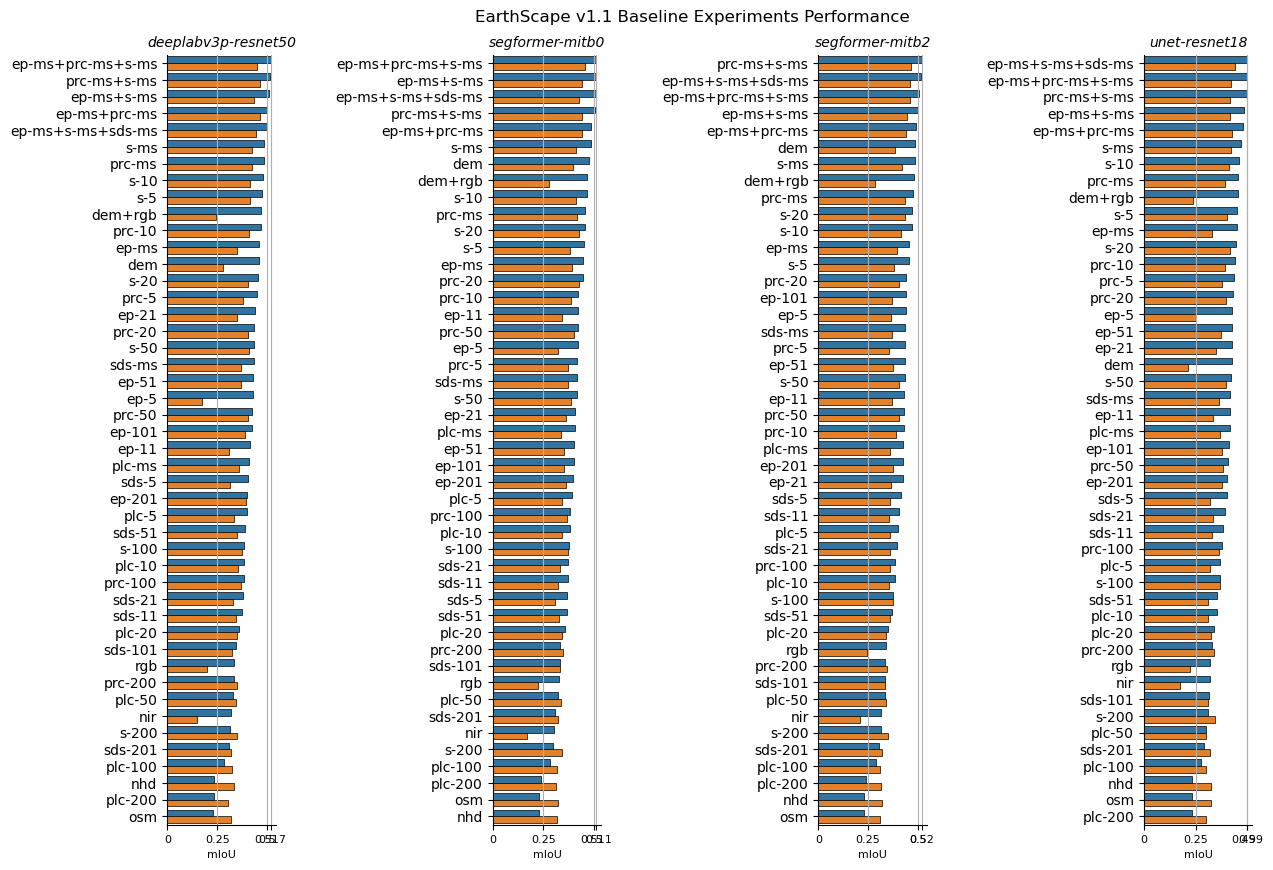

In [12]:
#############################################
# Modality Ranking Bar Charts - All Experiments
#############################################

# path to compiled data...
single_path = os.path.join(assets_dir, 'compiled_global.csv')
df_single = pd.read_csv(single_path)

# metric to plot...
metric = 'macro_iou'
metric_label = 'mIoU'

# models to use...
models = ['unet-resnet18', 'deeplabv3p-resnet50', 'segformer-mitb0', 'segformer-mitb2']


##### plot bar chart rankings...
fig, ax = plt.subplots(ncols=len(models), figsize=(3.5*len(models), 10))
plt.subplots_adjust(wspace=2)
ax = ax.ravel()

df_single['model-encoder'] = df_single['model'] + '-' + df_single['encoder']

idx = 0
for m in df_single['model-encoder'].unique():

    if m in models:

        df = df_single[df_single['model-encoder'] == m].copy()
        df.sort_values(f"{metric} (id)", ascending=False, inplace=True)
        order = df['input'].to_list()
        max_val = df[f"{metric} (id)"].max().item()
        df_plot = df.melt(id_vars=['input'], value_vars=[f"{metric} (id)", f"{metric} (cd)"], var_name='domain', value_name=metric)
        sns.barplot(ax=ax[idx], data=df_plot, x=metric, y='input', hue='domain', order=order, edgecolor='k', linewidth=0.5, legend=False)
        ax[idx].set_title(m, style='italic', fontsize=10)
        ax[idx].set_xticks([0, 0.25, 0.5, max_val])
        ax[idx].set_xticklabels(ax[idx].get_xticklabels(), fontsize=8)
        ax[idx].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.3f}".rstrip('0').rstrip('.')))
        idx += 1

for axes in ax:
    axes.set_xlabel(f"{metric_label}", fontsize=8)
    axes.set_ylabel('')
    axes.grid(visible=True, axis='x')
    axes.spines['right'].set_visible(False)
    axes.spines['top'].set_visible(False)

plt.suptitle(f"EarthScape v{VERSION} Baseline Experiments Performance", y=0.925)

plt.savefig(os.path.join(assets_dir, 'rankings.svg'), format='svg', bbox_inches='tight')
plt.show()

### Scale Sensitivity

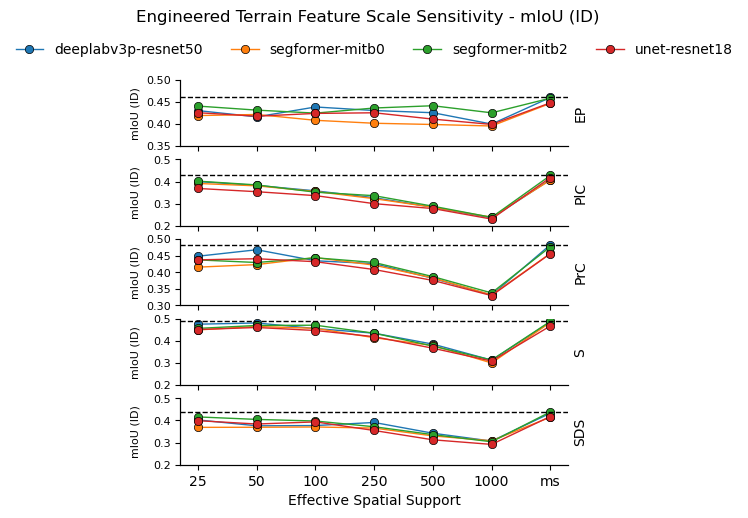

In [16]:
#############################################
# Terrain Feature Scale-Sensitivity - In-domain
#############################################

# path to compiled data...
compiled_path = os.path.join(assets_dir, 'compiled_global.csv')

# metric to plot...
metric = 'iou'
metric_label = 'mIoU (ID)'


##### pre-processing...
# read compiled data into df
df_compiled = pd.read_csv(compiled_path)

# parse input modality string into modality family & scale (e.g., ep-51 -> ep, 51)
df_compiled[['family', 'scale']] = df_compiled['input'].apply(lambda x: pd.Series(parse_features(x)))

# define raw sensor feature family & scale (native GSD)...
engineered_features = ['ep', 'plc', 'prc', 's', 'sds']
mask1 = df_compiled['family'] == 'multimodal'
mask2 = df_compiled['family'].isin(engineered_features)
df_compiled.loc[~mask1 & ~mask2, ['family', 'scale']] = 'raw', '5'

# define spatial support (effective recteptive area)...
support_bins = [25, 50, 100, 250, 500, 1000]
support_order = support_bins + ['ms']
df_compiled['spatial_support'] = df_compiled['scale'].apply(lambda x: spatial_support(x, support_bins))
df_compiled['spatial_support'] = pd.Categorical(df_compiled['spatial_support'], categories=support_order, ordered=True)

df_compiled['model-encoder'] = df_compiled['model'] + '-' + df_compiled['encoder']


##### plot...
fig, ax = plt.subplots(nrows=5, figsize=(5,5))
ax = ax.ravel()

# iterate through engineered terrain features...
for idx, fam in enumerate(engineered_features):

    # get terrain feature subset df
    subset = df_compiled[df_compiled['family'] == fam].copy()
    
    # iterate through model architectures & plot line with markers...
    for m in subset['model-encoder'].unique():
        df = subset[subset['model-encoder'] == m].copy()
        df.sort_values('spatial_support', ascending=True, na_position='last', inplace=True)
        df.reset_index(drop=True, inplace=True)
        df['spatial_support'] = df['spatial_support'].astype(str)
        ax[idx].plot(df['spatial_support'], df[f"macro_{metric} (id)"], marker='o', linewidth=1, markeredgecolor='k', markeredgewidth=0.5, label=m)

    max_val = subset[f"macro_{metric} (id)"].max()
    ax[idx].axhline(y=max_val, color='k', linewidth=1, linestyle='--')

    # customize plot...
    ylab = fam.upper() if not fam.startswith('p') else fam[:1].upper() + fam[1:2].lower() + fam[2:].upper()
    ax2 = ax[idx].twinx()
    ax2.set_yticks([])
    ax2.set_ylabel(ylab)
    ax[idx].set_ylabel(f"{metric_label}", fontsize=8)
    ax[idx].set_yticks(ax[idx].get_yticks())
    ax[idx].set_yticklabels(ax[idx].get_yticklabels(), fontsize=8)
    ax[idx].spines['right'].set_visible(False)
    ax[idx].spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['top'].set_visible(False)

# more plot customization...
ax[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.75), frameon=False, ncols=4)
ax[4].set_xlabel('Effective Spatial Support')
for axes in ax[:-1]:
    axes.set_xticklabels('')
    axes.set_xlabel('')
fig.align_ylabels()
plt.suptitle(f"Engineered Terrain Feature Scale Sensitivity - {metric_label}", y=1.02)

# plot and save...
# plt.savefig(os.path.join(assets_dir, 'scale_sensitivity_iou_id.png'), bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

### Cross-domain Robustness

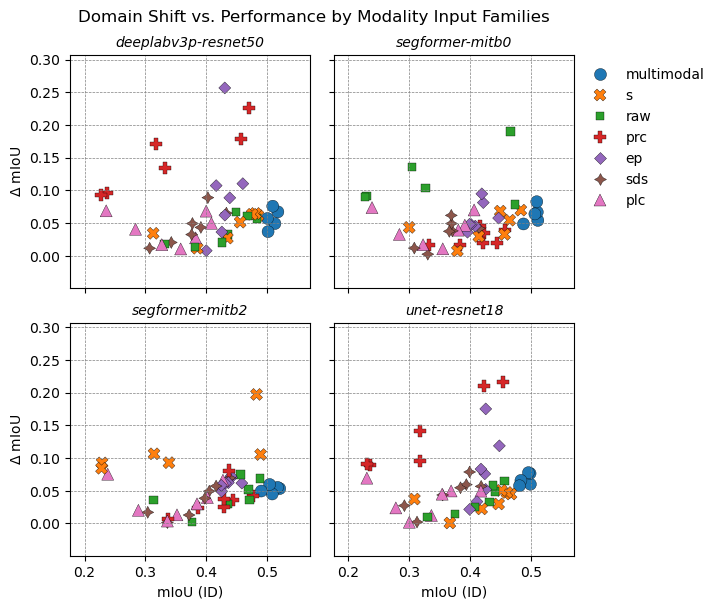

In [17]:
#############################################
# Cross-domain Performance - Delta Scatter plot
#############################################

# path to compiled data...
compiled_path = os.path.join(assets_dir, 'compiled_global.csv')

# metric to plot...
metric = 'macro_iou'
metric_label = 'mIoU'

# define variables...
engineered_features = ['ep', 'plc', 'prc', 's', 'sds']
support_bins = [25, 50, 100, 250, 500, 1000]
support_order = support_bins + ['ms']
size_map = {k:v for k, v in zip(support_order, np.arange(10, 175, 25))}
family_order = ['raw', 'ep', 'plc', 'prc', 's', 'sds', 'multimodal']


##### pre-processing...
# read compiled data into df
df_compiled = pd.read_csv(compiled_path)

# parse input modality string into modality family & scale (e.g., ep-51 -> ep, 51)
df_compiled[['family', 'scale']] = df_compiled['input'].apply(lambda x: pd.Series(parse_features(x)))

# define raw sensor feature family & scale (native GSD)...
mask1 = df_compiled['family'] == 'multimodal'
mask2 = df_compiled['family'].isin(engineered_features)
df_compiled.loc[~mask1 & ~mask2, ['family', 'scale']] = 'raw', '5'

# define spatial support (effective recteptive area)...
df_compiled['spatial_support'] = df_compiled['scale'].apply(lambda x: spatial_support(x, support_bins))
df_compiled['spatial_support'] = pd.Categorical(df_compiled['spatial_support'], categories=support_order, ordered=True)

# calculate cross-domain performance gap
df_compiled['delta'] = np.abs(df_compiled[f"{metric} (id)"] - df_compiled[f"{metric} (cd)"])

df_compiled['model-encoder'] = df_compiled['model'] + '-' + df_compiled['encoder']


#### plot delta scatter plot...
fig, ax = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True, figsize=(6.5,6.5))
fig.subplots_adjust(wspace=0.1, hspace=0.15)
ax = ax.ravel()

xmin = df_compiled[f"{metric} (id)"].min() - 0.05
xmax = df_compiled[f"{metric} (id)"].max() + 0.05
ymin = df_compiled['delta'].min() - 0.05
ymax = df_compiled['delta'].max() + 0.05

# iterate over model architectures...
models = df_compiled['model-encoder'].unique()
for idx, m in enumerate(models):

    # get subsets for specific architecture and multiscale...
    subset = df_compiled[df_compiled['model-encoder'] == m].copy()

    # plot scatterplot of each model architecture...
    legend = False
    if idx == 1:
        legend = True
    sns.scatterplot(ax=ax[idx], data=subset, x=f"{metric} (id)", y='delta', hue='family', style='family', s=75, linewidth=0.25, edgecolor='k', legend=legend)

    # customize plot...
    ax[idx].set_xlim(xmin, xmax)
    ax[idx].set_ylim(ymin, ymax)
    ax[idx].set_xlabel(f"{metric_label} (ID)")
    ylab = r'$\Delta$ ' + f"{metric_label}"
    ax[idx].set_ylabel(ylab)
    ax[idx].set_title(subset['model-encoder'].unique().item(), style='italic', fontsize=10)
    ax[idx].grid(axis='both', linestyle='--', linewidth=0.5, color='0.5')
    
# legend
ax[1].legend(loc='upper left', bbox_to_anchor=(1,1), frameon=False)
plt.suptitle('Domain Shift vs. Performance by Modality Input Families', y=0.95)

# plt.savefig(os.path.join(assets_dir, 'cross_performance_scatter_delta.png'), bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

### Performance vs. MMD

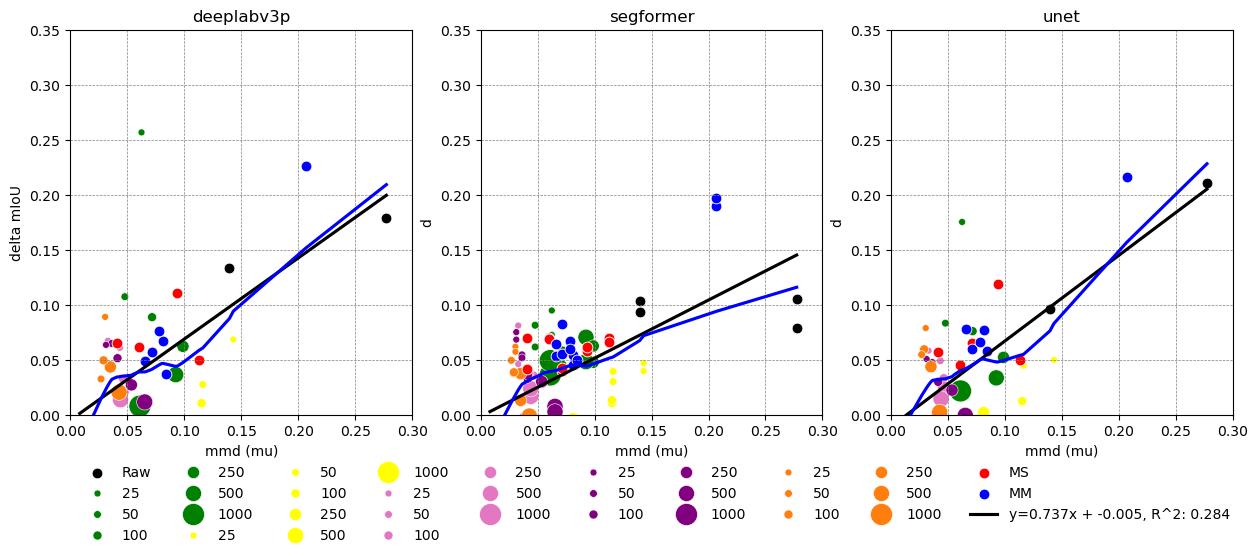

In [19]:

#############################################
# Performance vs. MMD
#############################################

# paths to compiled data...
compiled_path = os.path.join(assets_dir, 'compiled_global.csv')
mmd_path = glob.glob(r'../assets/data_eda/*mmd_summary.csv')[0]

# metric to plot...
metric = 'd'


##### pre-processing...
df_compiled = pd.read_csv(compiled_path)
df_compiled[["family", "spatial support"]] = df_compiled["input"].apply(parse_input_label)
df_mmd = pd.read_csv(mmd_path)
df = pd.merge(left=df_compiled, right=df_mmd, left_on='input', right_on='input', how='inner')


##### calculate regression & plot...
fig, ax = plt.subplots(ncols=3, figsize=(15,5))

for idx, m in enumerate(df['model'].unique()):
    mask = df['model'] == m
    subset = df[mask].copy()

    subset['d'] = subset['macro_iou (id)'] - subset['macro_iou (cd)']
    subset['dr'] = (subset['macro_iou (id)'] - subset['macro_iou (cd)']) / subset['macro_iou (id)'] * 100

    res = stats.linregress(subset["mmd (mu)"], subset[f"{metric}"])
    r2 = res.rvalue**2
    label = f"y={round(res.slope, 3)}x + {round(res.intercept, 3)}, R^2: {round(r2.item(), 3)}"

    sns.scatterplot(data=subset[subset['family'] == 'raw'], x='mmd (mu)', y=f"{metric}", ax=ax[idx], color='k', s=60, label='Raw')

    sns.scatterplot(data=subset[subset['family'] == 'ep'], x='mmd (mu)', y=f"{metric}", ax=ax[idx], color='green', size='spatial support', sizes=(25, 250))
    sns.scatterplot(data=subset[subset['family'] == 'plc'], x='mmd (mu)', y=f"{metric}", ax=ax[idx], color='yellow', size='spatial support', sizes=(25, 250))
    sns.scatterplot(data=subset[subset['family'] == 'prc'], x='mmd (mu)', y=f"{metric}", ax=ax[idx], color='tab:pink', size='spatial support', sizes=(25, 250))
    sns.scatterplot(data=subset[subset['family'] == 's'], x='mmd (mu)', y=f"{metric}", ax=ax[idx], color='purple', size='spatial support', sizes=(25, 250))
    sns.scatterplot(data=subset[subset['family'] == 'sds'], x='mmd (mu)', y=f"{metric}", ax=ax[idx], color='tab:orange', size='spatial support', sizes=(25, 250))

    sns.scatterplot(data=subset[subset['family'] == 'multi-scale'], x='mmd (mu)', y=f"{metric}", ax=ax[idx], color='red', s=60, label='MS')
    sns.scatterplot(data=subset[subset['family'] == 'multimodal'], x='mmd (mu)', y=f"{metric}", ax=ax[idx], color='blue', s=60, label='MM')

    x = sns.regplot(data=subset, x='mmd (mu)', y=f"{metric}", robust=False, ci=False, label=label, color='k', scatter=False, ax=ax[idx])
    sns.regplot(data=subset, x='mmd (mu)', y=f"{metric}", lowess=True, robust=False, ci=False, color='blue', scatter=False, ax=ax[idx])


    ax[idx].set_title(f"{m}")
    ax[idx].set_ylim(0, 0.35)
    ax[idx].set_xlim(0, 0.3)

    ax[idx].grid(axis='both', linestyle='--', linewidth=0.5, color='0.5')

for axes in ax:
    axes.legend().remove()
ax[0].legend(loc='upper left', bbox_to_anchor=(0,-0.1), frameon=False, ncols = 10)
ax[0].set_ylabel("delta mIoU")

plt.savefig(f"{assets_dir}/delta_vs_mmd_seg.svg", format='svg', bbox_inches='tight')
plt.show()

# **Class-wise Performance**

## *Experiment Compilation*

In [20]:
##################################################
# Compile Per-Class Performance Metrics - Single
##################################################

# initialize df
df_single = pd.DataFrame(columns=['model', 'encoder', 'input'])

# collect data from all experiments...
idx = 0
for d in single_dirs:
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0].split('-')[0]
    encoder_name = meta[0].split('-')[1]
    modalities = meta[1]

    # in-domain...
    id_global_path = os.path.join(d, 'id_overall_class.csv')
    id = pd.read_csv(id_global_path)
    id.set_index('class', inplace=True, drop=True)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_global_path = os.path.join(d, 'cd_overall_class.csv')
    cd = pd.read_csv(cd_global_path)
    cd.set_index('class', inplace=True, drop=True)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge in- & cross-domain subsets...
    df = pd.merge(left=id, right=cd, how='left', left_index=True, right_index=True)
    df.reset_index(inplace=True)

    # combine datasets...
    df_single = pd.concat([df_single, df], ignore_index=True, axis=0)
    df_single.loc[idx:idx+(len(df)), 'model'] = model_name
    df_single.loc[idx:idx+(len(df)), 'encoder'] = encoder_name
    df_single.loc[idx:idx+(len(df)), 'input'] = modalities

    idx += len(df)


df_single.head()

,model,encoder,input,class,gt_support (id),pred_support (id),gt_num_images (id),pred_num_images (id),tp (id),fp (id),...,macro_iou (cd),macro_dice (cd),macro_precision (cd),macro_recall (cd),mean_hd (cd),mean_hd95 (cd),micro_iou (cd),micro_dice (cd),micro_precision (cd),micro_recall (cd)
0,deeplabv3p,resnet50,dem,Qaf,10183.0,0.0,10.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000
1,deeplabv3p,resnet50,dem,Qal,8361713.0,7536136.0,947.0,928.0,5980234.0,1555902.0,...,0.137092,0.188426,0.314983,0.180292,141.442329,126.829787,0.228576,0.372099,0.608144,0.268055
2,deeplabv3p,resnet50,dem,Qat,388848.0,268789.0,61.0,60.0,94148.0,174641.0,...,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000
3,deeplabv3p,resnet50,dem,Qc,16237424.0,17202215.0,748.0,807.0,14663487.0,2538728.0,...,0.213697,0.275945,0.229029,0.435821,130.693717,111.436685,0.434113,0.605410,0.445544,0.944196
4,deeplabv3p,resnet50,dem,Qca,7202703.0,5861922.0,431.0,419.0,3971679.0,1890243.0,...,0.028692,0.045314,0.126181,0.039797,172.521181,158.150522,0.069393,0.129781,0.146740,0.116336


In [21]:
##################################################
# Compile Per-Class Performance Metrics - Multi-scale
##################################################

# initialize df
df_ms = pd.DataFrame(columns=['model', 'encoder', 'input'])

# collect data from all experiments...
idx = 0
for d in ms_dirs:
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0].split('-')[0]
    encoder_name = meta[0].split('-')[1]
    modalities = meta[1]

    # in-domain...
    id_global_path = os.path.join(d, 'id_overall_class.csv')
    id = pd.read_csv(id_global_path)
    id.set_index('class', inplace=True, drop=True)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_global_path = os.path.join(d, 'cd_overall_class.csv')
    cd = pd.read_csv(cd_global_path)
    cd.set_index('class', inplace=True, drop=True)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge in- & cross-domain subsets...
    df = pd.merge(left=id, right=cd, how='left', left_index=True, right_index=True)
    df.reset_index(inplace=True)

    # combine datasets...
    df_ms = pd.concat([df_ms, df], ignore_index=True, axis=0)
    df_ms.loc[idx:idx+(len(df)), 'model'] = model_name
    df_ms.loc[idx:idx+(len(df)), 'encoder'] = encoder_name
    df_ms.loc[idx:idx+(len(df)), 'input'] = modalities

    idx += len(df)


df_ms.head()

,model,encoder,input,class,gt_support (id),pred_support (id),gt_num_images (id),pred_num_images (id),tp (id),fp (id),...,macro_iou (cd),macro_dice (cd),macro_precision (cd),macro_recall (cd),mean_hd (cd),mean_hd95 (cd),micro_iou (cd),micro_dice (cd),micro_precision (cd),micro_recall (cd)
0,deeplabv3p,resnet50,ep-ms,Qaf,10183.0,0.0,10.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000
1,deeplabv3p,resnet50,ep-ms,Qal,8361713.0,8199411.0,947.0,1054.0,6680436.0,1518975.0,...,0.303881,0.375916,0.371760,0.473266,120.295557,104.006573,0.514143,0.679121,0.552783,0.880316
2,deeplabv3p,resnet50,ep-ms,Qat,388848.0,539226.0,61.0,109.0,172118.0,367108.0,...,0.016082,0.024768,0.063236,0.026466,178.579663,167.108281,0.045650,0.087315,0.067224,0.124535
3,deeplabv3p,resnet50,ep-ms,Qc,16237424.0,15833644.0,748.0,706.0,13838003.0,1995641.0,...,0.004168,0.006639,0.065462,0.004968,224.932480,206.073399,0.005830,0.011593,0.433847,0.005875
4,deeplabv3p,resnet50,ep-ms,Qca,7202703.0,5329902.0,431.0,371.0,3621076.0,1708826.0,...,0.008422,0.011123,0.017571,0.013183,185.029811,175.860970,0.020005,0.039224,0.168537,0.022195


In [22]:
##################################################
# Compile Per-Class Performance Metrics - Multimodal
##################################################

# initialize df
df_mm = pd.DataFrame(columns=['model', 'encoder', 'input'])

# collect data from all experiments...
idx = 0
for d in mm_dirs:
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0].split('-')[0]
    encoder_name = meta[0].split('-')[1]
    modalities = meta[1]

    # in-domain...
    id_global_path = os.path.join(d, 'id_overall_class.csv')
    id = pd.read_csv(id_global_path)
    id.set_index('class', inplace=True, drop=True)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_global_path = os.path.join(d, 'cd_overall_class.csv')
    cd = pd.read_csv(cd_global_path)
    cd.set_index('class', inplace=True, drop=True)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge in- & cross-domain subsets...
    df = pd.merge(left=id, right=cd, how='left', left_index=True, right_index=True)
    df.reset_index(inplace=True)

    # combine datasets...
    df_mm = pd.concat([df_mm, df], ignore_index=True, axis=0)
    df_mm.loc[idx:idx+(len(df)), 'model'] = model_name
    df_mm.loc[idx:idx+(len(df)), 'encoder'] = encoder_name
    df_mm.loc[idx:idx+(len(df)), 'input'] = modalities

    idx += len(df)


df_mm.head()

,model,encoder,input,class,gt_support (id),pred_support (id),gt_num_images (id),pred_num_images (id),tp (id),fp (id),...,macro_iou (cd),macro_dice (cd),macro_precision (cd),macro_recall (cd),mean_hd (cd),mean_hd95 (cd),micro_iou (cd),micro_dice (cd),micro_precision (cd),micro_recall (cd)
0,deeplabv3p,resnet50,dem+rgb,Qaf,10183.0,0.0,10.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000
1,deeplabv3p,resnet50,dem+rgb,Qal,8361713.0,7783900.0,947.0,945.0,6189999.0,1593901.0,...,0.021206,0.033100,0.132261,0.023510,158.595136,148.114965,0.024281,0.047411,0.734611,0.024496
2,deeplabv3p,resnet50,dem+rgb,Qat,388848.0,201869.0,61.0,55.0,74447.0,127422.0,...,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000
3,deeplabv3p,resnet50,dem+rgb,Qc,16237424.0,15958691.0,748.0,781.0,14308856.0,1649835.0,...,0.084895,0.124819,0.287199,0.112029,172.168721,156.376829,0.133184,0.235061,0.611706,0.145483
4,deeplabv3p,resnet50,dem+rgb,Qca,7202703.0,6794139.0,431.0,424.0,4537760.0,2256379.0,...,0.022104,0.034479,0.136336,0.027778,182.633431,170.731542,0.041124,0.078999,0.194659,0.049555


In [26]:
##################################################
# Compile All Global Experiments
##################################################

# compile data...
df = pd.concat([df_single, df_ms, df_mm])
df.reset_index(drop=True, inplace=True)
df.to_csv(os.path.join(assets_dir, 'compiled_class.csv'), index=False)

df.head()

,model,encoder,input,class,gt_support (id),pred_support (id),gt_num_images (id),pred_num_images (id),tp (id),fp (id),...,macro_iou (cd),macro_dice (cd),macro_precision (cd),macro_recall (cd),mean_hd (cd),mean_hd95 (cd),micro_iou (cd),micro_dice (cd),micro_precision (cd),micro_recall (cd)
0,deeplabv3p,resnet50,dem,Qaf,10183.0,0.0,10.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000
1,deeplabv3p,resnet50,dem,Qal,8361713.0,7536136.0,947.0,928.0,5980234.0,1555902.0,...,0.137092,0.188426,0.314983,0.180292,141.442329,126.829787,0.228576,0.372099,0.608144,0.268055
2,deeplabv3p,resnet50,dem,Qat,388848.0,268789.0,61.0,60.0,94148.0,174641.0,...,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000
3,deeplabv3p,resnet50,dem,Qc,16237424.0,17202215.0,748.0,807.0,14663487.0,2538728.0,...,0.213697,0.275945,0.229029,0.435821,130.693717,111.436685,0.434113,0.605410,0.445544,0.944196
4,deeplabv3p,resnet50,dem,Qca,7202703.0,5861922.0,431.0,419.0,3971679.0,1890243.0,...,0.028692,0.045314,0.126181,0.039797,172.521181,158.150522,0.069393,0.129781,0.146740,0.116336


In [28]:
df['encoder'].unique()

array(['resnet50', 'mitb0', 'mitb2', 'resnet18'], dtype=object)

## *Visualizations*

### Performance vs. Class-area Proportion

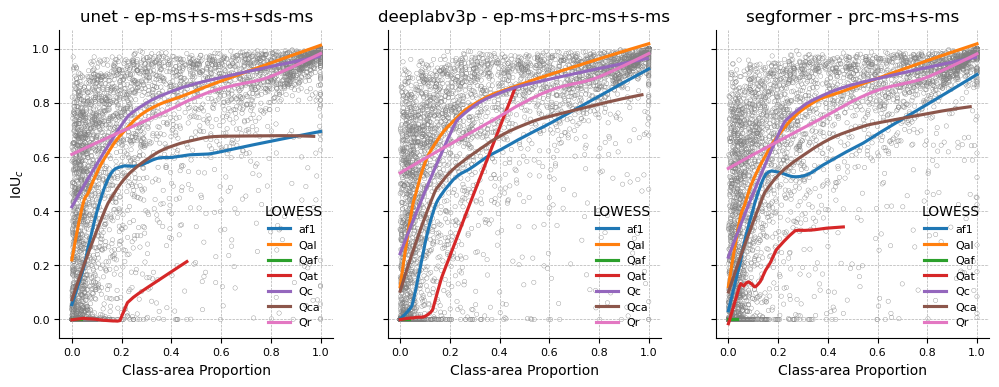

In [70]:
#############################################
# Class Performance vs. Class-area in Sample
#############################################

# class area proportions path
areas_path = glob.glob(r'../data/*areas.csv')[0]

# model-best input dictionary
model_input_dict = {
    'unet_resnet18': 'ep-ms+s-ms+sds-ms', 
    'deeplabv3p_resnet50': 'ep-ms+prc-ms+s-ms',
    'segformer_mitb2': 'prc-ms+s-ms',
    }

# root directory containing all experiments
exp_root = r'../experiments/baselines/segmentation'


##### plot...
# read areas dataframe 
areas = pd.read_csv(areas_path)
areas.set_index('patch_id', drop=True, inplace=True)
col_order = areas.columns

# set up figure...one subplot for each model
fig, ax = plt.subplots(ncols=3, sharey=True, figsize=(12,4))

# iterate through each model experiment...
idx = 0
for model_encoder, input in model_input_dict.items():

    model, encoder = model_encoder.split('_')

    exp_dir = glob.glob(os.path.join(exp_root, "**", f"*{model}*{encoder}*{input}*"))
    exp_dir = [d for d in exp_dir if 'variance' not in d][0]

    path = os.path.join(exp_dir, "id_img_class.csv")
    preds = pd.read_csv(path)                                                           # read predictions into dataframe
    preds = preds[['patch_id', 'class', 'iou']]

    preds_pivot = preds.pivot(index="patch_id", columns="class", values="iou").reset_index()
    preds_pivot.columns.name = None
    preds_pivot.set_index('patch_id', drop=True, inplace=True)
    preds_pivot = preds_pivot[col_order]


    df = preds_pivot.join(areas, on='patch_id', how='left', rsuffix='_area')

    # define class probability & class area proportions columns...
    area_cols = [col for col in df.columns if 'area' in col]
    prob_cols = [col.split('_')[0] for col in area_cols]

    # iterate through each class...
    for a, p in zip(area_cols, prob_cols):

        df2 = df[[a, p]].copy()     # subset dataframe for class of interest
        df2 = df2[df2[a] > 0]       # only process patches with class presence

        # plot lowess curve...
        sns.regplot(ax=ax[idx], data=df2, x=a, y=p, lowess=True, scatter=False, label=p)
        sns.scatterplot(ax=ax[idx], data=df2, x=a, y=p, edgecolor='0.5', s=10, facecolor='none')

    # customize plot...
    ax[idx].legend(loc='lower right', bbox_to_anchor=(1, 0), frameon=False, fontsize=8, title='LOWESS')
    ax[idx].set_title(f"{model} - {input}")
    ticks = np.arange(0, 1.01, 0.2)
    ax[idx].set_xlabel('Class-area Proportion')
    ax[idx].set_xticks(ticks)
    ax[idx].set_xticklabels(ax[idx].get_xticklabels(), fontsize=8)
    ax[idx].set_yticks(ticks)
    ax[idx].set_yticklabels([])
    ax[idx].set_ylabel('')
    ax[idx].grid(axis='both', linewidth=0.5, linestyle='--')
    ax[idx].spines['right'].set_visible(False)
    ax[idx].spines['top'].set_visible(False)

    idx += 1

# set y axis for first plot...
ax[0].set_ylabel(r'$\text{IoU}_c$')
ax[0].set_yticks(ticks)
ax[0].set_yticklabels([str(round(s, 1)) for s in ticks], fontsize=8)

plt.savefig(os.path.join(assets_dir, 'prob_vs_area.svg'), format='svg', bbox_inches='tight')
plt.show()

### Class Performance Heatmap

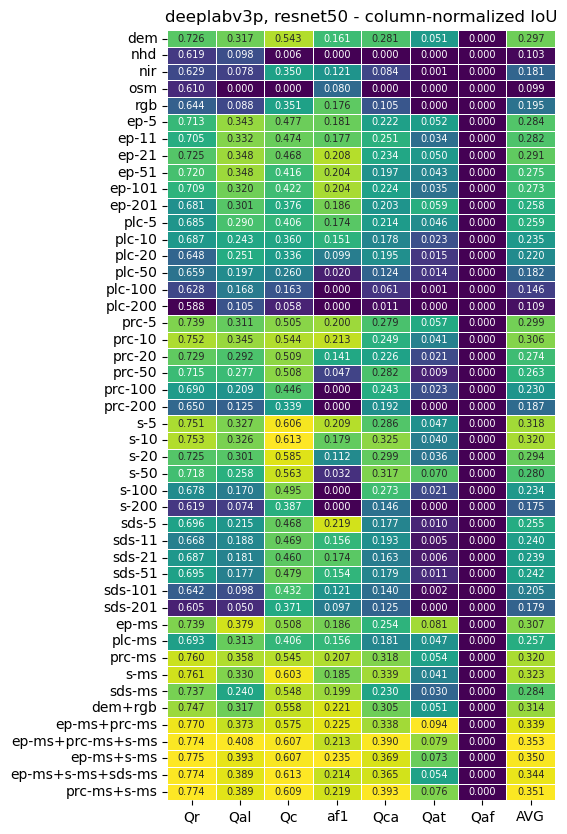

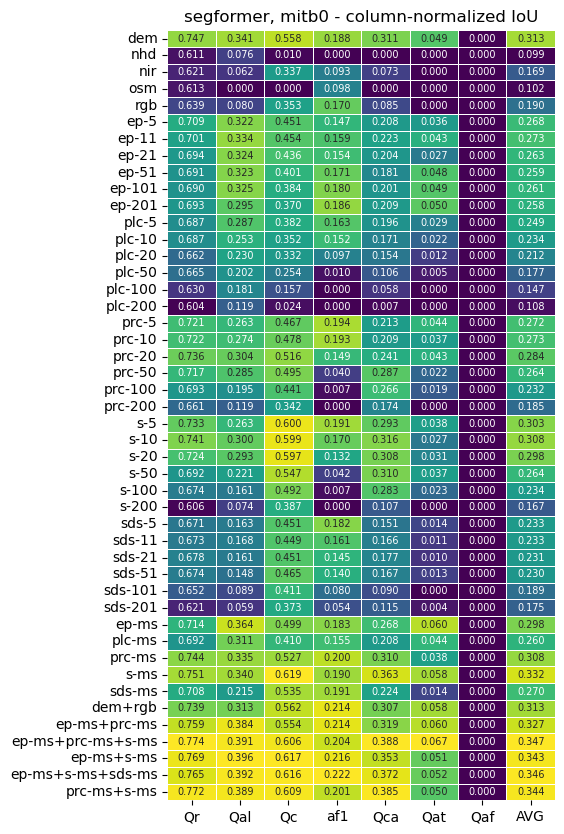

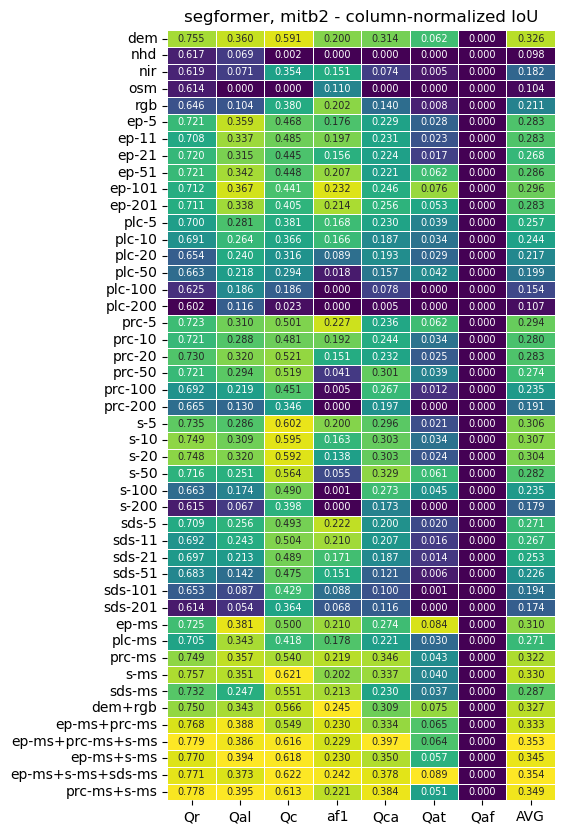

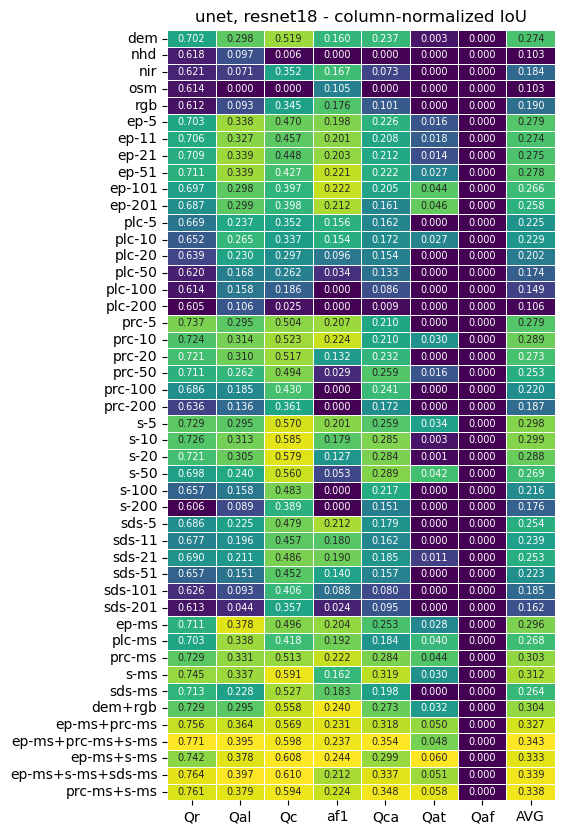

In [108]:
#############################################
# Class-level Heatmap with Macro-Average
#############################################

# path to compiled class metrics
class_path = os.path.join(f"{assets_dir}/compiled_class.csv")


##### pre-processing & plotting...
df = pd.read_csv(class_path)

# iterate through each model separately...
for model, encoder in df[['model', 'encoder']].drop_duplicates().to_records(index=False):

    mask = (df['model'] == model) & (df['encoder'] == encoder)
    subset = df[mask].copy()
    subset = subset[['model', 'encoder', 'input', 'class', 'macro_iou (id)']]

    subset_pivot = subset.pivot(index=['model', 'encoder', 'input'], columns='class', values='macro_iou (id)')
    subset_pivot.columns.name = None
    subset_pivot.reset_index(drop=False, inplace=True)

    # parse data in fixed order...
    subset_pivot[["family", "spatial support"]] = subset_pivot["input"].apply(parse_input_label)

    # fixed orders for plotting...
    class_order = ["Qr", "Qal", "Qc", "af1", "Qca", "Qat", "Qaf"]
    heatmap_order = class_order + ["AVG"]
    family_rank = {"raw": 0, "ep": 1, "plc": 2, "prc": 3, "s": 4, "sds": 5, "multi-scale": 6, "multimodal": 7}
    support_families = ["ep", "plc", "prc", "s", "sds"]

    # map orders to dataframe subset...
    subset_pivot["family_rank"] = subset_pivot["family"].map(family_rank)
    subset_pivot["support_sort"] = np.where(subset_pivot["family"].isin(support_families), pd.to_numeric(subset_pivot["spatial support"], errors="coerce"), np.nan)
    subset_pivot["alpha_sort"] = subset_pivot["input"].astype(str).str.lower()
    subset_pivot = subset_pivot.sort_values(by=["family_rank", "support_sort", "alpha_sort"], na_position="last")
    row_order = subset_pivot["input"].drop_duplicates()

    # create heatmap dataframe by pivoting...
    heatmap_df = subset_pivot[['input']+class_order].set_index('input').loc[row_order]
    heatmap_df['AVG'] = heatmap_df[class_order].mean(axis=1)

    # produce normalized (max-min) dataframe for plotting...
    heatmap_norm = (heatmap_df - heatmap_df.min(axis=0)) / (heatmap_df.max(axis=0) - heatmap_df.min(axis=0))
    heatmap_norm.fillna(0, inplace=True)

    ##### plot heatmap...
    fig, ax = plt.subplots(figsize=(5,10))

    sns.heatmap(
        heatmap_norm[heatmap_order],
        annot=heatmap_df[heatmap_order],
        fmt=".3f",
        cmap="viridis",
        linewidths=0.5,
        annot_kws={'fontsize': 7},
        cbar=False,
        ax=ax
        )

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(f"{model}, {encoder} - column-normalized IoU")

    plt.savefig(os.path.join(assets_dir, f"class_heatmap_{model}_{encoder}.svg"), format='svg', bbox_inches='tight')
    plt.show()


### Example Predicted Masks

In [ ]:
#############################################
# Example Segmentation Masks by Performance Category
#############################################

# modality configuration
exp = 'ep-ms+prc-ms+s-ms'

# relevant experiment directories (modality config fun in all models)
exp_dirs = glob.glob(f"../experiments/baselines/segmentation/**/*{exp}*")

# model predictions of in-domain test set
pred_paths = [os.path.join(d, 'id_img_class.csv') for d in exp_dirs]

# class area proportions...
areas_path = glob.glob(r'../data/*areas.csv')[0]

# ouput path
output_path = os.path.join(assets_dir, 'example_masks.png')

seed = 111



##### pre-processing & plotting...
# setup plot
fig, ax = plt.subplots(nrows=4, ncols=8, figsize=(16, 8))
ax = ax.ravel()

# define color map using standard colors
cmap = ListedColormap(list(SG_COLORS.values()))

# initialize subplot row number...
row = 0

# iterate through img/class metrics files for each model-encoder... 
for path in pred_paths:


    ###### pre-processing....
    # read img/class CSV to df
    df = pd.read_csv(path)
    
    # filter samples...
    mask1 = (df['gt_support'] > 0) | (df['pred_support'] > 0)              # rows with true or predicted classes in patch...
    mask2 = df.groupby('patch_id')['gt_present'].transform('sum') > 1      # at least two classes present
    df = df[mask1 & mask2]

    # aggregate class metrics to patch-level performance (single metric per sample)...
    patch_summary = df.groupby('patch_id').apply(lambda x: pd.Series({'weighted_iou': np.average(x['iou'], weights=x['gt_support'])}))
    patch_summary['weighted_iou'] = patch_summary['weighted_iou'].clip(0., 1.)

    # create performance/area bins...
    patch_summary['bin'] = pd.cut(patch_summary['weighted_iou'], bins=[0., .25, .5, .75, 1.], labels=['Q1', 'Q2', 'Q3', 'Q4'], include_lowest=True)

    # randomly sample one patch per bin...
    samples = patch_summary.groupby('bin').apply(lambda x: x.sample(1, random_state=seed)).reset_index()


    ##### evaluate selected samples with model & pre-trained weights...
    # get relevant paths...
    exp_dir = os.path.abspath(os.path.dirname(path))     # experiment directory
    config_path = os.path.join(exp_dir, 'config.yml')    # path to config.yml file for experiment
    with open(config_path, 'r') as file:                 # open config.yml as dict
        cfg = yaml.safe_load(file)
    ckpt_path = cfg['experiment']['best_model']          # path to best model / checkpoint .pth file

    # define model parameters...
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model_name = cfg['model']['model_name']
    encoder_name = cfg['model']['encoder_name']
    in_channels = cfg['model']['in_channels']
    output_size = cfg['model']['output_size']

    # initialize correct model & load weights...
    if model_name == 'unet':
        model = create_unet_seg(in_channels=in_channels, num_classes=output_size, encoder_name=encoder_name).to(device)
    elif model_name == 'deeplabv3p':
        model = create_deeplabv3p_seg(in_channels=in_channels, num_classes=output_size, encoder_name=encoder_name).to(device)
    elif model_name == 'segformer':
        model = create_segformer_seg(in_channels=in_channels, num_classes=output_size, encoder_name=encoder_name).to(device)
    state_dict = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state_dict)

    # collect required input information for dataloader...
    inp = cfg['data']['input'][exp]
    channels = inp['channels']                                                     # number of input channels
    means = inp['mean']                                                            # list of means for input channels
    sds = inp['sd']                                                                # list of standard dev. for input channels
    patch_dirs = [f"../{cfg['data']['root']}/{d}" for d in cfg['data']['dirs']]    # directory paths containing data channels/modalities


    ##### plot masks...
    # initialize subplot column number
    col = 0

    # iterate through four sample selections (based on performance/difficulty)...
    for _, sample in samples.iterrows():

        # create input dataloader...
        input_dict = {exp: {'channels': channels, 'mean': means, 'sd': sds}}
        ds = ESDataset_Classification([sample['patch_id']], patch_dirs, input_dict, areas_path, task='segmentation')
        dl = DataLoader(ds)

        # evaluate sample with model & get prediction & target masks...
        prediction, mask = test_model_seg(model, dl, device)
        prediction = prediction.squeeze(0)
        mask = mask.squeeze(0)

        # plot target & prediction masks side-by-side (fix colors to 0-6)
        ax[col+row].imshow(mask, cmap=cmap, vmin=0, vmax=6)
        ax[col+row+1].imshow(prediction, cmap=cmap, vmin=0, vmax=6)

        # plot model-encoder name along y-axis on left column only...
        if col == 0:
            ax[col+row].text(-0.15, 0.5, f"{model_name}\n({encoder_name})", transform=ax[col+row].transAxes, fontsize=10, rotation=90, ha='center', va='center')
        
        # increase column number by 2
        col += 2

    # increase row number by 8 (for 8 subplots per row)
    row += 8

# turn off axis ticks/labels...
for axes in ax:
    axes.set_xticks([])
    axes.set_yticks([])
    for spine in axes.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(0.5)

# plot GT/Predicted titles...
for j in range(8):
    if j % 2 == 0:
        ax[j].set_title("GT", fontsize=10, style='italic')
    else:
        ax[j].set_title("Predicted", fontsize=10, style='italic')

# plot performance/difficulty category...
pair_centers = [(1/8)*(1.5*k+1)+0.1 for k in range(4)]
bin_labels = ["Wt. IoU: 0-0.25", "Wt. IoU: 0.25-0.5", "Wt. IoU: 0.5-0.75", "Wt. IoU: 0.75-1.0"]
for x, label in zip(pair_centers, bin_labels):
    fig.text(x, 0.93, label, ha='center', va='center', fontsize=12)

plt.suptitle('Randomly Selected Examples by Weighted IoU of In-domain Ground Truth and Predicted Segmentation Masks')
# plt.savefig(output_path, bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

# **Correlations**

## *Dataset Class Imbalance*

In [ ]:
#############################################
# In-domain Performance vs. Class Frequency
#############################################

# paths to compiled data...
compiled_path = os.path.join(assets_dir, 'compiled_class.csv')
stats_path = glob.glob(r'../assets/data_eda/*imbalance_metrics.csv')[0]

response = 'macro_iou (id)'
predictor = 'N_eff'

##### pre-processing & calculate correlation...
df_compiled = pd.read_csv(compiled_path)
df_stats = pd.read_csv(stats_path)
df = pd.merge(left=df_compiled, right=df_stats, how='inner', on='class')


df_corr = pd.DataFrame({
    "r2": df.groupby(['model', 'encoder', 'input']).apply(lambda g: g[predictor].corr(g[response], method="pearson"))**2,
    "pcc": df.groupby(['model', 'encoder', 'input']).apply(lambda g: g[predictor].corr(g[response], method="pearson")),
    "srcc": df.groupby(['model', 'encoder', 'input']).apply(lambda g: g[predictor].corr(g[response], method="spearman")),
    "krcc": df.groupby(['model', 'encoder', 'input']).apply(lambda g: g[predictor].corr(g[response], method="kendall"))
    })

df_corr_avg = df_corr.groupby(['model', 'encoder']).mean().reset_index()
df_corr_avg.to_csv(f"{assets_dir}/correlation_n_effective.csv", index=False)
df_corr_avg

,model,encoder,r2,pcc,srcc,krcc
0,deeplabv3p,resnet50,0.640645,0.795002,0.872779,0.762181
1,segformer,mitb0,0.627558,0.786687,0.869974,0.759747
2,segformer,mitb2,0.647922,0.799026,0.871125,0.760541
3,unet,resnet18,0.648704,0.799571,0.893067,0.785082


## *Intra-patch Spatial Support*

In [120]:
#############################################
# Correlation of Class Performance vs. Spatial Support
#############################################

# class area proportions path
areas_path = glob.glob(r'../data/*areas.csv')[0]

# model-best input dictionary
model_input_dict = {
    'unet_resnet18': 'ep-ms+s-ms+sds-ms', 
    'deeplabv3p_resnet50': 'ep-ms+prc-ms+s-ms',
    'segformer_mitb2': 'prc-ms+s-ms',
    }

# root directory containing all experiments
exp_root = r'../experiments/baselines/segmentation'


##### plot...
# read areas dataframe 
areas = pd.read_csv(areas_path)
areas.set_index('patch_id', drop=True, inplace=True)
col_order = areas.columns

# initialize dataframe to hold correlations
df_corr = pd.DataFrame(columns=['model', 'input', 'r2', 'pcc', 'srcc', 'krcc'])

# iterate through each model experiment...
idx = 0
for model_encoder, input in model_input_dict.items():

    model, encoder = model_encoder.split('_')

    exp_dir = glob.glob(os.path.join(exp_root, "**", f"*{model}*{encoder}*{input}*"))
    exp_dir = [d for d in exp_dir if 'variance' not in d][0]

    path = os.path.join(exp_dir, "id_img_class.csv")
    preds = pd.read_csv(path)                                                           # read predictions into dataframe
    preds = preds[['patch_id', 'class', 'iou']]

    preds_pivot = preds.pivot(index="patch_id", columns="class", values="iou").reset_index()
    preds_pivot.columns.name = None
    preds_pivot.set_index('patch_id', drop=True, inplace=True)
    preds_pivot = preds_pivot[col_order]

    df = preds_pivot.join(areas, on='patch_id', how='left', rsuffix='_area')

    # define class probability & class area proportions columns...
    area_cols = [col for col in df.columns if 'area' in col]
    prob_cols = [col.split('_')[0] for col in area_cols]

    # iterate through each class...
    corr = pd.DataFrame(columns=['r2', 'pcc', 'srcc', 'krcc'])
    idx2 = 0
    for a, p in zip(area_cols, prob_cols):

        df2 = df[[a, p]].copy()     # subset dataframe for class of interest
        df2 = df2[df2[a] > 0]       # only process patches with class presence

        corr.loc[idx2, 'r2'] = df2[a].corr(df2[p], method='pearson')**2
        corr.loc[idx2, 'pcc'] = df2[a].corr(df2[p], method='pearson')
        corr.loc[idx2, 'srcc'] = df2[a].corr(df2[p], method='spearman')
        corr.loc[idx2, 'krcc'] = df2[a].corr(df2[p], method='kendall')

        idx2 += 1

    df_corr.loc[idx, 'model'] = model
    df_corr.loc[idx, 'input'] = input
    df_corr.loc[idx, 'r2'] = corr['r2'].mean()
    df_corr.loc[idx, 'pcc'] = corr['pcc'].mean()
    df_corr.loc[idx, 'srcc'] = corr['srcc'].mean()
    df_corr.loc[idx, 'krcc'] = corr['krcc'].mean()

    idx += 1

df_corr.to_csv(f"{assets_dir}/correlation_area.csv", index=False)
df_corr.head()

,model,input,r2,pcc,srcc,krcc
0,unet,ep-ms+s-ms+sds-ms,0.293171,0.532001,0.65155,0.486173
1,deeplabv3p,ep-ms+prc-ms+s-ms,0.385447,0.619311,0.695693,0.528562
2,segformer,prc-ms+s-ms,0.314322,0.549362,0.643254,0.482428


## *Inter-region Geographic Robustness*

In [111]:
###################################
# Performance Degradation vs. MMD
###################################

# paths to compiled data...
compiled_path = os.path.join(assets_dir, 'compiled_global.csv')
mmd_path = glob.glob(r'../assets/data_eda/*mmd_summary.csv')[0]

metric = 'macro_iou'
response = 'delta'
predictor = 'mmd (mu)'

##### pre-processing & calculate correlation...
df_compiled = pd.read_csv(compiled_path)
df_mmd = pd.read_csv(mmd_path)
df = pd.merge(left=df_compiled, right=df_mmd, how='inner', on='input')
df['delta'] = df[f"{metric} (id)"] - df[f"{metric} (cd)"]

df_corr = pd.DataFrame({
    "r2": df.groupby(['model', 'encoder']).apply(lambda g: g[predictor].corr(g[response], method="pearson"))**2,
    "pcc": df.groupby(['model', 'encoder']).apply(lambda g: g[predictor].corr(g[response], method="pearson")),
    "srcc": df.groupby(['model', 'encoder']).apply(lambda g: g[predictor].corr(g[response], method="spearman")),
    "krcc": df.groupby(['model', 'encoder']).apply(lambda g: g[predictor].corr(g[response], method="kendall"))
    }).reset_index()

df_corr.to_csv(f"{assets_dir}/correlation_mmd.csv", index=False)
df_corr

,model,encoder,r2,pcc,srcc,krcc
0,deeplabv3p,resnet50,0.283849,0.532775,0.350066,0.238384
1,segformer,mitb0,0.248828,0.498826,0.402767,0.270707
2,segformer,mitb2,0.287142,0.535856,0.370356,0.274747
3,unet,resnet18,0.384005,0.619682,0.369433,0.244444


# **Model Variance**

## *Global Variance - Best Inputs*

In [123]:
#############################################
# Model Performance Variance
#############################################

# model-best input dictionary
model_input_list = [
    ('unet', 'resnet18', 's-10'),
    ('unet', 'resnet18', 's-ms'),
    ('unet', 'resnet18', 'ep-ms+s-ms+sds-ms'),

    ('deeplabv3p', 'resnet50', 's-10'),
    ('deeplabv3p', 'resnet50', 's-ms'),
    ('deeplabv3p', 'resnet50', 'ep-ms+prc-ms+s-ms'),

    ('segformer', 'mitb2', 'dem'),
    ('segformer', 'mitb2', 's-ms'),
    ('segformer', 'mitb2', 'prc-ms+s-ms'),

    ]

# root directory containing all experiments
exp_root = r'../experiments/baselines/segmentation/variance'

metric = 'macro_iou'


df = pd.DataFrame(columns=['model', 'input', f"{metric}_id_mean", f"{metric}_id_sd", f"{metric}_cd_mean", f"{metric}_cd_sd"])

rows = []

for model, encoder, input_name in model_input_list:

    exp_dirs = glob.glob(os.path.join(exp_root, f"{model}*{encoder}*{input_name}*"))
    exp_dirs = [d for d in exp_dirs if 'variance' in d]

    id_list = []
    cd_list = []

    for d in exp_dirs:
        id_path = os.path.join(d, 'id_overall.csv')
        cd_path = os.path.join(d, 'cd_overall.csv')

        id_df = pd.read_csv(id_path)
        cd_df = pd.read_csv(cd_path)

        id_list.append(id_df)
        cd_list.append(cd_df)

    df_id = pd.concat(id_list, ignore_index=True)
    df_cd = pd.concat(cd_list, ignore_index=True)

    rows.append({
        'model': model,
        'encoder': encoder,
        'input': input_name,
        f"{metric}_id_mean": df_id[metric].mean(),
        f"{metric}_id_sd": df_id[metric].std(),
        f"{metric}_cd_mean": df_cd[metric].mean(),
        f"{metric}_cd_sd": df_cd[metric].std(),
    })

df = pd.DataFrame(rows)
df.to_csv(f"{assets_dir}/variance.csv", index=False)
df.head(12)

,model,encoder,input,macro_iou_id_mean,macro_iou_id_sd,macro_iou_cd_mean,macro_iou_cd_sd
0,unet,resnet18,s-10,0.461047,0.001658,0.410419,0.006572
1,unet,resnet18,s-ms,0.482079,0.012228,0.420894,0.016552
2,unet,resnet18,ep-ms+s-ms+sds-ms,0.489706,0.011290,0.429032,0.018301
3,deeplabv3p,resnet50,s-10,0.471678,0.010901,0.419190,0.010666
4,deeplabv3p,resnet50,s-ms,0.497945,0.017011,0.432852,0.014193
5,deeplabv3p,resnet50,ep-ms+prc-ms+s-ms,0.512044,0.004474,0.443198,0.008269
6,segformer,mitb2,dem,0.480275,0.010799,0.385983,0.013572
7,segformer,mitb2,s-ms,0.502917,0.010855,0.443990,0.015173
8,segformer,mitb2,prc-ms+s-ms,0.512459,0.004695,0.454234,0.007698
